# Data Generation

## Lotka-Volterra model: well-specified

In [ ]:
from diffrax import diffeqsolve, ODETerm, Dopri5, SaveAt, Tsit5, PIDController
import jax.numpy as jnp

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('ggplot')


import jax
import numpy as np
#jax.config.update("jax_enable_x64", True)
import jax.random as jrandom

import time
from functools import partial

cd = jnp.array([0.4, 0.02])
c, d = 0.4, 0.02
def transform(args):
    args = jax.nn.sigmoid(args)
    return jnp.stack([args.at[1].multiply(-1), cd], 0)

def lvfunc(t, y, args):
    u, v = y
    a, b = jax.nn.sigmoid(args)
    du = a * u - b * u * v
    dv = -c * v + d * u * v
    nugget = 1e-6
    return jnp.array([du, dv]) + nugget

#true_param_vals = jnp.array([-2, -4]) + 0.0
true_param_vals = jnp.array([-1, -3]) + 0.0

#x_init = jnp.ones((2,)) * 10.0
x_init = jnp.array([10.0, 15.0])

tmax = 80.0
tobs = 60.0

ts = jnp.linspace(0.0, tobs, 100)

stepsize_controller = PIDController(rtol=1e-5, atol=1e-5)
term = ODETerm(lvfunc)
solver = Dopri5()
saveat = SaveAt(ts=ts)

p = jax.nn.sigmoid(true_param_vals)
ratio = p[1]/p[0]
true_params = jnp.array([true_param_vals[0], jax.scipy.special.logit(ratio)])

solution = diffeqsolve(term, solver, t0=0, t1=tmax, dt0=0.05, y0=x_init, saveat=SaveAt(dense=True), args=true_param_vals, stepsize_controller=stepsize_controller)

## Lotka-Volterra: misspecified

In [2]:
from diffrax import ControlTerm, Euler, MultiTerm, VirtualBrownianTree, ReversibleHeun, SEA, HalfSolver, ItoMilstein
key = jrandom.PRNGKey(14) # 15

rng, key = jrandom.split(key)
diff_coef = jnp.diag(jnp.array([0.2, 0.2]))
diffusion = lambda t, y, args: diff_coef

brownian_motion = VirtualBrownianTree(t0=0, t1=tmax, tol=1e-3, shape=(2,), key=rng)
terms = MultiTerm(ODETerm(lvfunc), ControlTerm(diffusion, brownian_motion))
solver = ItoMilstein()#HalfSolver(SEA()) #Euler()
saveat = SaveAt(dense=True)

stepsize_controller = PIDController(pcoeff=0.1, icoeff=0.3, rtol=1e-3, atol=1e-3)

sol = diffeqsolve(terms, solver, t0=0, t1=tmax, dt0=0.1, y0=x_init, saveat=saveat, args=true_param_vals)

In [3]:
noise_sigma = 1.0
ts = jnp.linspace(0, tobs, 120)[1:]

obs_1 = jax.vmap(solution.evaluate)(ts)
obs_2 = jax.vmap(sol.evaluate)(ts)

rng, key = jrandom.split(key)
obs_1 += noise_sigma * jrandom.normal(rng, obs_1.shape)
rng, key = jrandom.split(key)
obs_2 += noise_sigma * jrandom.normal(rng, obs_2.shape)

In [4]:
# plot L-V misspecified
# Note: some misspecified solution can be numerically unstable - you might need to choose a random seed that produces trajectories like below


plt.subplot(1, 2, 1)
plt.title("Well-specified")
plt.scatter(ts, obs_1[:, 0])
plt.scatter(ts, obs_1[:, 1])
t1 = jnp.linspace(0, tmax, 1000)
tj = jax.vmap(solution.evaluate)(t1)
plt.plot(t1, tj[:, 0], c='k', linestyle='--', alpha=0.5)
plt.plot(t1, tj[:, 1], c='k', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.title("Misspecified")
plt.scatter(ts, obs_2[:, 0])
plt.scatter(ts, obs_2[:, 1])

tj = jax.vmap(sol.evaluate)(t1)
plt.plot(t1, tj[:, 0], c='k', linestyle='--', alpha=0.5)
plt.plot(t1, tj[:, 1], c='k', linestyle='--', alpha=0.5)

In [5]:
def build_lotka_volterra(y0, ts, params):
    # use parameters to simulate trajectories
    def lvfunc(t, y, args):
        u, v = y
        #a, b = args
        a = jax.nn.sigmoid(args[0])
        b = a * jax.nn.sigmoid(args[1])
        
        #a, b = jax.nn.sigmoid(args) # transform
        du = a * u - b * u * v
        dv = -c * v + d * u * v
        nugget = 1e-10
        return jnp.array([du, dv]) + nugget
        
    term = ODETerm(lvfunc)
    solver = Tsit5()
    saveat = SaveAt(ts=ts)
    stepsize_controller = PIDController(rtol=1e-5, atol=1e-5)
    return diffeqsolve(term, solver, t0=ts[0], t1=ts[-1], dt0=0.05, y0=y0, saveat=saveat, args=params, stepsize_controller=stepsize_controller).ys

In [6]:
# kernel follows a normal density function
ls2 = 1.0
kernel = lambda x, mu, s2: jnp.exp(jnp.sum(-0.5 * jnp.log(2*jnp.pi*s2) - 0.5 * jnp.square(x-mu)/s2 + 0.5 * jnp.log(2*jnp.pi*ls2)))

# default lengthscale value

def build_first_variation(y0, ts, obs, reg_const):
    # this function returns the first variation given the observations (ts, obs), the initial state y0
    def particle_updates_marginalized(params_set, params_set2=None):
        # this function takes a set of particles (params_set) as input, and outputs the first variation of L(Q)
        # the gradient of this function is the drift term for mean-field Langevin diffusion
        n_particles = params_set.shape[0]
        if params_set2 is None:
            params_set2 = params_set.copy()
        params_set2 = jax.lax.stop_gradient(params_set2)
        trajs1 = jax.vmap(build_lotka_volterra, (None, None, 0))(y0, ts, params_set)
        trajs2 = jax.vmap(build_lotka_volterra, (None, None, 0))(y0, ts, params_set2)
            
        s2 = jnp.square(noise_sigma)
            
        def calculate_V(tj):
            kxy = jax.vmap(kernel, (0, 0, None))(obs, tj, s2 + ls2)
            return jnp.sum(kxy)
                
        def calculate_W(tj1, tj2):
            kxy = jax.vmap(kernel, (0, 0, None))(tj2, tj1, 2 * s2 + ls2)
            return jnp.sum(kxy)
                
        Vs = jax.vmap(calculate_V)(trajs1)
        Ws = jax.vmap(jax.vmap(calculate_W, (None, 0)), (0, None))(trajs1, trajs2)
        Ws = jnp.sum(Ws, 1) / n_particles
        #Ws = Ws.at[jnp.diag_indices_from(Ws)].set(0.0)
        #Ws = jnp.sum(Ws, 1) / (n_particles - 1)
            
        return jnp.sum(Vs - Ws) / reg_const
        
    return particle_updates_marginalized

In [ ]:
def se_kernel(x, y, ell):
    return jnp.exp(-0.5 * jnp.sum(jnp.square((x-y) / ell)))

def imq_kernel(x, y, ell):
    c = 1
    beta = -0.5
    return jnp.power(jnp.square(c) + jnp.sum(jnp.square((x-y) / ell)), beta)

def kernel_wrapper(kernel_func):
    def kf(x, y):
        k = kernel_func(x, y)
        dkdx = jax.grad(kernel_func, 0)(x, y)
        dkdy = jax.grad(kernel_func, 1)(x, y)
        ddk = jnp.sum(jnp.diagonal(jax.jacobian(jax.grad(kernel_func, 1), 0)(x, y)))
        return k, dkdx, dkdy, ddk

    ks = jax.value_and_grad(kernel_func, 1)
    ks_gram = lambda xs: jax.vmap(jax.vmap(ks, (None, 0)), (0, None))(xs, xs)
    return kf, ks_gram

def compute_kgd(kernel_func):
    kf, _ = kernel_wrapper(kernel_func)
    def kgd(x, y, scx, scy):
        k, dk1, dk2, t3 = kf(x, y)
        t1 = jnp.sum(scx * scy) * k
        t2 = jnp.sum(dk1 * scy) + jnp.sum(dk2 * scx)
        return t1 + t2 + t3
    kgd_mapped = jax.vmap(jax.vmap(kgd, (0, None, 0, None)), (None, 0, None, 0))
    return lambda xs, scs: jnp.mean(kgd_mapped(xs, xs, scs, scs))

In [8]:
def langevin(drift_func, kernel_func, n_iters, dt0, params_init, key):
    # mean-field Langevin diffusion
    params = params_init
    trace = []
    kgd_trace = []
    kgd_func = compute_kgd(kernel_func)
    
    for i in range(n_iters):
        #print(i)
        rng, key = jrandom.split(key)
        ll, g = drift_func(params)

        g -= params #(params - true_param_vals)
        discrepancy = kgd_func(params, g)
        kgd_trace.append(discrepancy)
        
        params_new = params + dt0 * g + jnp.sqrt(2 * dt0) * jrandom.normal(rng, params.shape)
        params = params_new
        
        trace.append(params.copy())
        
        if (i+1) % 1000 == 0:
            print('{}: {}'.format(i+1, ll))
            
    return trace, kgd_trace

In [9]:
#ks = jax.value_and_grad(se_kernel, 1)
#ks_gram = jax.vmap(jax.vmap(ks, (None, 0, None)), (0, None, None))
#ks = jax.value_and_grad(imq_kernel, 1)
#ks_gram = jax.vmap(jax.vmap(ks, (None, 0, None)), (0, None, None))
import optax

def kernel_vgd(drift_func, kernel_func, n_iters, dt0, params_init):
    trace = []
    kgd_trace = []
    
    optimizer = optax.adam(dt0)
    params = params_init
    n_particles = params.shape[0]
    opt_state = optimizer.init(params)
    kf, ks_gram = kernel_wrapper(kernel_func)

    def kgd(x, y, scx, scy):
        k, dk1, dk2, t3 = kf(x, y)
        t1 = jnp.sum(scx * scy) * k
        t2 = jnp.sum(dk1 * scy) + jnp.sum(dk2 * scx)
        return t1 + t2 + t3
        
    #kgd_mapped = jax.vmap(jax.vmap(kgd, (0, None, 0, None)), (None, 0, None, 0))
    kgd_func = compute_kgd(kernel_func)
    
    for i in range(n_iters):
        kx, dkx = ks_gram(params)
        ll, g = drift_func(params)
        g -= params #(params - true_param_vals)
        
        #discrepancy = jnp.mean(kgd_mapped(params, params, g, g))
        discrepancy = kgd_func(params, g)
        kgd_trace.append(discrepancy)
        
        dx = (jnp.matmul(kx, g) + jnp.sum(dkx, 1)) / n_particles
        #params_new = params + dt0 * updates
        # params_new = params + dt0 * g - dt0 * reg_const * params + jnp.sqrt(2 * reg_const * dt0) * jrandom.normal(rng, params.shape)
        #params = params_new
        updates, opt_state = optimizer.update(-dx, opt_state)
        params = optax.apply_updates(params, updates)

        trace.append(params.copy())
        
        if (i+1) % 1000 == 0:
            print('{}: {}'.format(i+1, ll))
            
    return trace, kgd_trace

In [10]:
def plot_ci(axis, x_init, ts, obs, params, solfunc):
    t0 = jnp.linspace(0.0, tmax, 500)
    trajs = jax.vmap(build_lotka_volterra, (None, None, 0))(x_init, t0, params)
    t1 = jnp.sort(trajs, 0)
    ms = jnp.mean(t1, 0)
    stds = jnp.std(t1, 0)
    quart = 0.67448

    #smin = t1[3, :, :]
    #smax = t1[-4, :, :]
    #ms = jnp.mean(t1[3:-3, :, :], 0)
    
    tr = jax.vmap(solfunc)(t0)     
    #axis.fill_between(t0, smin[:, 0], smax[:, 0], color='gray', alpha=.5)
    #axis.fill_between(t0, smin[:, 1], smax[:, 1], color='gray', alpha=.5)

    axis.fill_between(t0, ms[:, 0] - quart * stds[:, 0], ms[:, 0] + quart * stds[:, 0], color='gray', alpha=.5)
    axis.fill_between(t0, ms[:, 1] - quart * stds[:, 1], ms[:, 1] + quart * stds[:, 1], color='gray', alpha=.5)
    
    line1, = axis.plot(t0, tr[:, 0], c='C0', label=r'$u_1$')
    points1 = axis.scatter(ts, obs[:, 0], marker='o', edgecolor='C0', s=20, facecolors='none', label='prey data', linewidth=1)
    
    line2, = axis.plot(t0, tr[:, 1], c='C1', linestyle='dashed', label=r'$u_2$')
    points2 = axis.scatter(ts, obs[:, 1], marker='^', edgecolor='C1', s=20, facecolors='none', label='predator data', linewidth=1)
    return axis, [line1, line2, points1, points2]

# Mean-field LD: well-specified

In this example, we can see that in the well-specified model, PCUQ does not deviate away from the ground-truth parameter value. 

In [11]:
reg_const = 1.0

drift_func = jax.value_and_grad(jax.jit(build_first_variation(x_init, ts, obs_1, reg_const)), 0)

# Calculating KGD requires s_pq(x) = drift_func(x) - x

n_particles = 25
step_size = 1e-5

kernel_func = lambda x, y: imq_kernel(x, y, 0.01) + imq_kernel(x, y, 0.1) + imq_kernel(x, y, 1.0)

params_init = jnp.stack([true_params] * n_particles, 0)
rng, key = jrandom.split(key)
params_init += 1e-5 * jrandom.normal(rng, params_init.shape)

traces_ld, kgd_traces_ld = langevin(drift_func, kernel_func, 5000, step_size, params_init, key)

fig, axs = plt.subplots(4, 2, figsize=(6, 12))

a = np.array(traces_ld)

ax, handles = plot_ci(axs[1][0], x_init, ts, obs_1, traces_ld[-1], solution.evaluate)

for i in range(n_particles):
    axs[0][0].plot(a[:, i, 0], c='r')
    axs[0][0].plot(a[:, i, 1], c='b')

axs[0][0].set_title("MFLD trajectory")

trs = jnp.array(traces_ld[-250:]).reshape((-1, 2))
axs[2][0].scatter(trs[:, 0], trs[:, 1], marker='x', s=5)

axs[3][0].plot(jnp.log(jnp.array(kgd_traces_ld)))
axs[3][0].set_title("MFLD KGD trace (log)")

n_particles = 25
params_init = jnp.stack([true_params] * n_particles, 0)
rng, key = jrandom.split(key)
params_init += 1e-5 * jrandom.normal(rng, params_init.shape)

step_size = 1e-3
traces_vgd, kgd_traces_vgd = kernel_vgd(drift_func, kernel_func, 5000, step_size, params_init)

a = np.array(traces_vgd)

for i in range(n_particles):
    axs[0][1].plot(a[:, i, 0], c='r')
    axs[0][1].plot(a[:, i, 1], c='b')

axs[0][1].set_title("VGD trajectory")

ax, handles = plot_ci(axs[1][1], x_init, ts, obs_1, traces_vgd[-1], solution.evaluate)

axs[2][1].scatter(traces_vgd[-1][:, 0], traces_vgd[-1][:, 1], marker='x', s=5)

axs[3][1].plot(jnp.log(jnp.array(kgd_traces_vgd)))
axs[3][1].set_title("VGD KGD trace (log)")

plt.savefig("lv-vgd.png")

KeyboardInterrupt: 

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey=True, sharex=True)

trs = jnp.array(traces_ld[-1]).reshape((-1, 2))
axs[0].scatter(trs[:, 0], trs[:, 1], marker='x', s=15)
axs[0].scatter(traces_vgd[-1][:, 0], traces_vgd[-1][:, 1], marker='x', s=15)

axs[1].scatter(traces_vgd[-1][:, 0], traces_vgd[-1][:, 1], marker='x', s=15)

# Mean-field LD: misspecified

In [14]:
import pickle

# Chargement depuis le fichier
with open("results_pcuq.pkl", "rb") as g:
    results_pcuq = pickle.load(g)

In [15]:
reg_const = 0.1
drift_func = jax.value_and_grad(jax.jit(build_first_variation(x_init, ts, obs_2, reg_const)), 0)

# Calculating KGD requires s_pq(x) = drift_func(x) - x

n_particles = 25
step_size = 1e-5

kernel_func = lambda x, y: imq_kernel(x, y, 0.01) + imq_kernel(x, y, 0.1) + imq_kernel(x, y, 1.0)

params_init = jnp.stack([true_params] * n_particles, 0)
rng, key = jrandom.split(key)
params_init += 1e-3 * jrandom.normal(rng, params_init.shape)
#params_init = jrandom.normal(rng, params_init.shape)

traces_ld, kgd_traces_ld = langevin(drift_func, kernel_func, 5000, step_size, params_init, key)

fig, axs = plt.subplots(4, 2, figsize=(6, 15))

a = np.array(traces_ld)

ax, handles = plot_ci(axs[1][0], x_init, ts, obs_2, traces_ld[-1], sol.evaluate)

for i in range(n_particles):
    axs[0][0].plot(a[:, i, 0], c='r')
    axs[0][0].plot(a[:, i, 1], c='b')

axs[0][0].set_title("MFLD trajectory")

trs = jnp.array(traces_ld[-250:]).reshape((-1, 2))
axs[2][0].scatter(trs[:, 0], trs[:, 1], marker='x', s=5)

axs[3][0].plot(jnp.log(jnp.array(kgd_traces_ld)))
axs[3][0].set_title("MFLD KGD trace (log)")

step_size = 1e-3
traces_vgd, kgd_traces_vgd = kernel_vgd(drift_func, kernel_func, 5000, step_size, params_init)

a = np.array(traces_vgd)

for i in range(n_particles):
    axs[0][1].plot(a[:, i, 0], c='r')
    axs[0][1].plot(a[:, i, 1], c='b')

axs[0][1].set_title("VGD trajectory")

ax, handles = plot_ci(axs[1][1], x_init, ts, obs_2, traces_vgd[-1], sol.evaluate)

axs[2][1].scatter(traces_vgd[-1][:, 0], traces_vgd[-1][:, 1], marker='x', s=5)

axs[3][1].plot(jnp.log(jnp.array(kgd_traces_vgd)))
axs[3][1].set_title("VGD KGD trace (log)")

plt.savefig("lv-vgd-ms1.png")

1000: 123.50135040283203
2000: 103.84043884277344
3000: 167.51014709472656
4000: 152.57774353027344
5000: 100.92747497558594
1000: -411.2068176269531
2000: 119.1077880859375
3000: 168.4666748046875
4000: 170.91065979003906
5000: 179.80252075195312


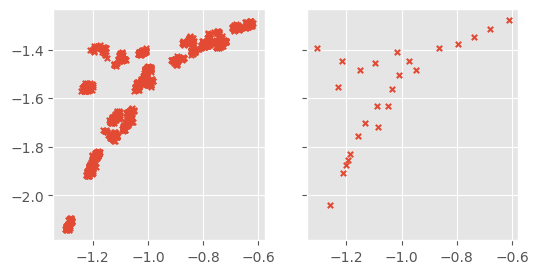

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey=True, sharex=True)

trs = jnp.array(traces_ld[-50:]).reshape((-1, 2))
axs[0].scatter(trs[:, 0], trs[:, 1], marker='x', s=15)


axs[1].scatter(traces_vgd[-1][:, 0], traces_vgd[-1][:, 1], marker='x', s=15)
plt.show()

In [ ]:
# results_pcuq = {
#     "MFLD contour": {
#         "X_fin": None,
#         "KGD": None
#     },
#     "MFLD": {
#         "X_fin": None,
#         "KGD": None
#     },

#     "Extensible sampling": {
#         "X_fin": None,
#         "KGD_values": None},

#     "Variational gradient descent": {
#         "X_fin": None,
#         "KGD_values": None
#     }
# }

In [27]:
results_pcuq["MFLD"]["X_fin"] = traces_ld[-1]
results_pcuq["Variational gradient descent"]["X_fin"] = traces_vgd[-1]
results_pcuq["MFLD"]["KGD"] = kgd_traces_ld
results_pcuq["Variational gradient descent"]["KGD_values"] = kgd_traces_vgd

# Misspecified case Extensible sampling


In [132]:
from extensible_sampling import ExtensibleSampling
from jax import jit, vmap
gamma = 10.0
drift_func = jax.value_and_grad(jax.jit(build_first_variation(x_init, ts, obs_2,gamma)), 0)
gradL = jit(lambda X : -drift_func(X)[1])

# c = jnp.array(1.0)
# b = 0.5
# ell = 0.1
# def k(x,y):
#     return (c**2 + jnp.sum(jnp.square((x-y) / ell)))**(-b)
key = jrandom.PRNGKey(2024)
n_particles = 25
params_init = jnp.stack([true_params] * n_particles, 0)
rng, key = jrandom.split(key)
params_init += 1e-5 * jrandom.normal(rng, params_init.shape)

def q_0(x):
    d = x.shape[0]
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 * jnp.pi)**d)

def grad_log_q0(x):
    return -x

# k = jit(k)
# q_0 = jit(q_0)

L = 0
T = 25

# c_es = jnp.array(1.0)
# b_es = 1/2
# ell_es = 1.0
# def k_es(x,y):
#     return jnp.exp(-jnp.sum(jnp.square((x-y) / ell_es)))
#            #(c**2 + jnp.sum(jnp.square((x-y) / ell)))**(-b)

def k_imq(x, y, c, b, scale=1.):
  assert b > 0
  return (c**2 + (x-y).dot(x-y)/scale**2)**(-b)

def imq_scale_mixtures(x, y, scales):
  return  vmap(lambda scale: k_imq(x, y, 1, 0.5, scale))(scales).mean()

scales = jnp.array([0.03,0.1])
k_es = lambda x,y : imq_scale_mixtures(x,y,scales) #lambda x, y: imq_kernel(x, y, 0.01) + imq_kernel(x, y, 0.1) + imq_kernel(x, y, 1.0)
k_es = jit(k_es)

ES = ExtensibleSampling(q_0,L,k_es,gradL=gradL, grad_log_q0=grad_log_q0)

x0 = params_init[0] #jnp.array([-1.0,-3.0]) + 1e-4 * jrandom.normal(key,shape =2)#params_init
n0 = 70
X_fin = ES.run_particles(x0,T,min_research = "prior_search",l = -4,u = -0.5,n0 = n0)

Iteration: 10
Iteration: 20


In [3]:
#Upload results
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open("results_pcuq.pkl", "rb") as g:
    results_pcuq = pickle.load(g)

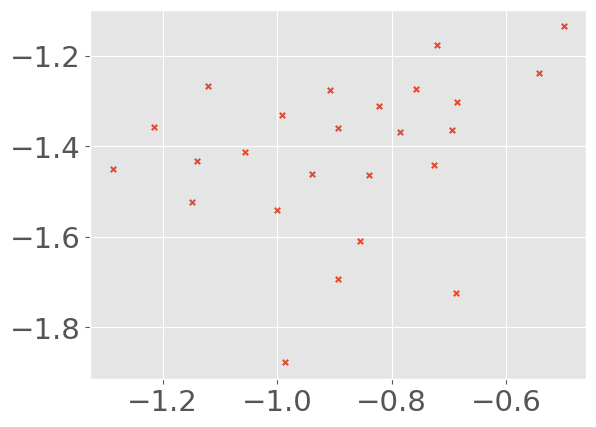

In [134]:
plt.scatter(X_fin[:,0],X_fin[:,1],marker='x',s=15)
plt.show()

In [151]:
KGD_values = []
for i in range(1,T+1):
    KGD_values.append(compute_kgd(kernel_func)(X_fin[:i],drift_func(X_fin[:i])[1] - X_fin[:i]))

In [153]:
results_pcuq["Extensible Sampling"]["X_fin"] = X_fin
results_pcuq["Extensible Sampling"]["KGD_values"] = KGD_values

In [4]:
# correction KGD^2 --> KGD
results_pcuq["Extensible Sampling"]["KGD_values"] = jnp.sqrt(jnp.array(results_pcuq["Extensible Sampling"]["KGD_values"]))
results_pcuq["MFLD"]["KGD_values"] = jnp.sqrt(jnp.array(results_pcuq["MFLD"]["KGD_values"]))
results_pcuq["Variational Gradient Descent"]["KGD_values"] = jnp.sqrt(jnp.array(results_pcuq["Variational Gradient Descent"]["KGD_values"]))


# MFLD for the contour 

In [47]:
reg_const = 0.1
drift_func = jax.value_and_grad(jax.jit(build_first_variation(x_init, ts, obs_2, reg_const)), 0)

# Calculating KGD requires s_pq(x) = drift_func(x) - x

n_particles = 100
step_size = 1e-6

kernel_func = lambda x, y: imq_kernel(x, y, 0.01) + imq_kernel(x, y, 0.1) + imq_kernel(x, y, 1.0)

params_init = jnp.stack([true_params] * n_particles, 0)
rng, key = jrandom.split(key)
params_init += 1e-3 * jrandom.normal(rng, params_init.shape)
#params_init = jrandom.normal(rng, params_init.shape)

traces_ld_contour, kgd_traces_ld_contour = langevin(drift_func, kernel_func, 100000, step_size, params_init, key)

1000: -1105.05810546875
2000: 211.41909790039062
3000: 631.4273681640625
4000: 795.308349609375
5000: 767.5564575195312
6000: 858.39990234375
7000: 839.2733154296875
8000: 959.0711669921875
9000: 942.3660278320312
10000: 836.4080810546875
11000: 887.4996948242188
12000: 918.8489990234375
13000: 945.1463623046875
14000: 844.1817626953125
15000: 893.7911376953125
16000: 904.864013671875
17000: 766.0195922851562
18000: 830.036376953125
19000: 946.7391357421875
20000: 927.42529296875
21000: 983.729736328125
22000: 971.739013671875
23000: 948.7508544921875
24000: 946.163330078125
25000: 994.30322265625
26000: 885.7735595703125
27000: 874.4155883789062
28000: 843.9470825195312
29000: 961.6038818359375
30000: 952.9273071289062
31000: 991.98193359375
32000: 974.9346313476562
33000: 976.264892578125
34000: 950.7333984375
35000: 929.7802734375
36000: 899.290771484375
37000: 1007.5347900390625
38000: 999.534912109375
39000: 987.2435302734375
40000: 993.8306274414062
41000: 1042.9893798828125
4200

In [48]:
results_pcuq["MFLD contour"]["X_fin"] = traces_ld_contour[-1]

save results

In [5]:
import pickle

# Sauvegarde dans un fichier binaire
with open("results_pcuq.pkl", "wb") as gg:
    pickle.dump(results_pcuq, gg)

Upload results

In [6]:
#Upload results
import pickle

# Chargement depuis le fichier
with open("results_pcuq.pkl", "rb") as g:
    results_pcuq_loaded = pickle.load(g)

In [7]:
def kde_mfld(x):
    X = results_pcuq_loaded["MFLD contour"]["X_fin"][:,:2]
    n = X.shape[0]
    h = 1.0 / jnp.sqrt(n)

    diff = (X - x) / h
    sq_dist = jnp.sum(diff**2, axis=1)

    norm_const = 1.0 / (n * (2 * jnp.pi)**(X.shape[1] / 2) * h**X.shape[1])

    density = norm_const * jnp.sum(jnp.exp(-0.5 * sq_dist))
    return density

In [12]:
import matplotlib
# font options
font = {
#     'family' : 'normal',
    #'weight' : 'bold',
    'size'   : 22
}
matplotlib.rc('font', **{'family': 'serif', })
plt.rc('font', **font)
plt.rc('lines', linewidth=3, markersize=10)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

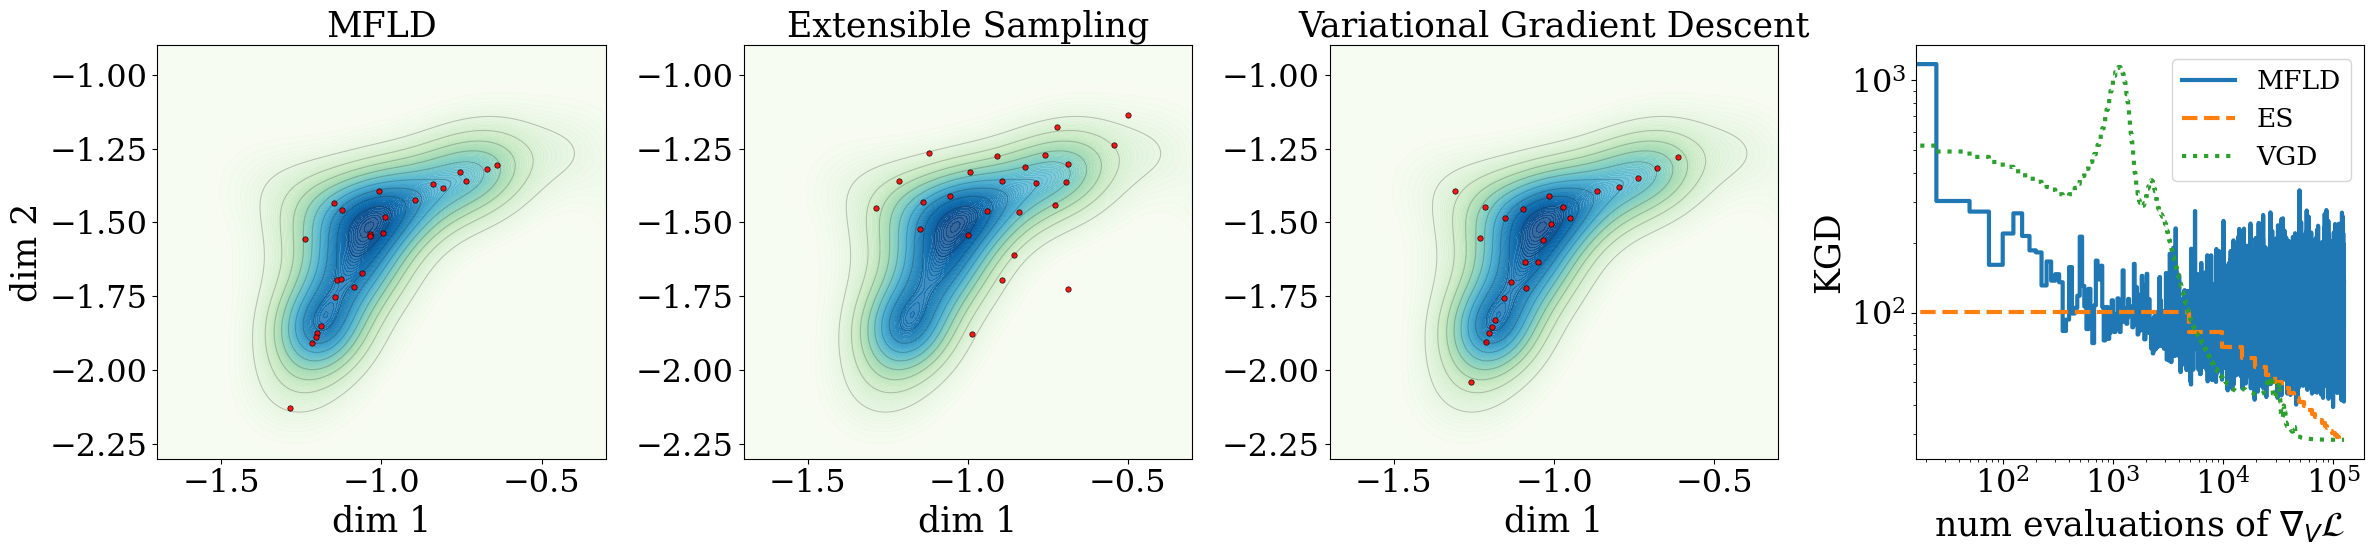

In [13]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

x = jnp.linspace(-1.7, -0.3, 200)
y = jnp.linspace(-2.3, -0.9, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld(jnp.array([x, y])) for x in x] for y in y])

plt.rcParams.update({
    'axes.titlesize': 25,        # Taille des titres des axes
    'axes.labelsize': 25,        # Taille des labels des axes
    'xtick.labelsize': 23,       # Taille des ticks sur l'axe x
    'ytick.labelsize': 23,       # Taille des ticks sur l'axe y
    'legend.fontsize': 19,       # Taille de la légende
    'figure.titlesize': 25       # Taille du titre global (si utilisé)
})

#plt.style.use('default')
fig, axes = plt.subplots(1, 4, figsize=(16*1.5, 4*1.5))

for ind, expe in enumerate(list(results_pcuq_loaded.keys())[1:]):
    
    # Fond dégradé avec transparence
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.8     # transparence du fond
    )
    
    # Lignes de contour par-dessus
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.2
    )
    
    # Points très contrastés
    axes[ind].scatter(
        results_pcuq_loaded[expe]["X_fin"][:, 0],
        results_pcuq_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    axes[ind].set_title(expe)
    axes[ind].set_xlabel('dim 1')
    axes[ind].set_ylabel('dim 2')
    #axes[ind].legend()
axes[1].set_ylabel("")
axes[2].set_ylabel("")

tab_ODE_solved = 10**2 * jnp.arange(0,5000) #25
axes[3].set_facecolor('white')

evaluations_grad_L = jnp.arange(0,len(results_pcuq_loaded["MFLD"]["KGD_values"])) * len(results_pcuq_loaded["MFLD"]["X_fin"])
n0 = 70
evaluations_grad_L_ES = jnp.arange(0,len(results_pcuq_loaded["Extensible Sampling"]["KGD_values"])) * n0**2
axes[3].step(evaluations_grad_L,
    results_pcuq_loaded["MFLD"]["KGD_values"], 
    label="MFLD", 
    linestyle='-'
)
axes[3].step(evaluations_grad_L_ES,
    results_pcuq_loaded["Extensible Sampling"]["KGD_values"], 
    label="ES", 
    linestyle='--'
)
axes[3].step(evaluations_grad_L,
    results_pcuq_loaded["Variational Gradient Descent"]["KGD_values"], 
    label="VGD", 
    linestyle=':'
)
axes[3].legend()
axes[3].set_xscale("log")
axes[3].set_yscale("log")
axes[3].set_xlabel(r"num evaluations of $\nabla_V \mathcal{L}$")
axes[3].set_ylabel("KGD")
#plt.title("KGD")
plt.tight_layout()

plt.savefig("fig3.png", format="png")


plt.show()

In [ ]:
# results_pcuq = {
#     "MFLD contour": {
#         "X_fin": None,
#         "KGD_values": None
#     },
#     "MFLD": {
#         "X_fin": None,
#         "KGD_values": None
#     },

#     "Extensible Sampling": {
#         "X_fin": None,
#         "KGD_values": None},

#     "Variational Gradient Descent": {
#         "X_fin": None,
#         "KGD_values": None
#     }
# }

In [ ]:
# results_pcuq["MFLD"]["X_fin"] = results_pcuq_loaded["MFLD"]["X_fin"]
# results_pcuq["Variational Gradient Descent"]["X_fin"] = results_pcuq_loaded["Variational gradient descent"]["X_fin"]
# results_pcuq["MFLD"]["KGD_values"] = results_pcuq_loaded["MFLD"]["KGD"]
# results_pcuq["Variational Gradient Descent"]["KGD_values"] = results_pcuq_loaded["Variational gradient descent"]["KGD_values"]
# results_pcuq["MFLD contour"]["X_fin"] = results_pcuq_loaded["MFLD contour"]["X_fin"]
# results_pcuq["Extensible Sampling"]["X_fin"] = results_pcuq_loaded["Extensible sampling"]["X_fin"]
# results_pcuq["Extensible Sampling"]["KGD_values"] = results_pcuq_loaded["Extensible sampling"]["KGD_values"]

In [ ]:

# with open("results_pcuq.pkl", "wb") as gg:
#     pickle.dump(results_pcuq, gg)